#Sistema de Análisis de Sensores de Temperatura
## Calificación de Equipos Isotérmicos - v8.0 ULTIMATE

**Nuevas funcionalidades v8:**
- Corrección por interpolación (T1, C1, T2, C2 por sensor)
- Tasa de muestreo seleccionable (30s, 1min, 2min, 5min, 10min)
- Segmentación por hora:minuto (sin pérdida de datos)
- Sin forward fill (espacios vacíos cuando no hay datos)
- Corrección variable por cada dato crudo

**Proceso automatizado:**
1. Lectura de archivos de múltiples sensores
2. Configuración de parámetros y trazabilidad
3. Segmentación de datos por fecha/hora
4. Aplicación de correcciones por interpolación
5. Generación de tablas y gráficas
6. Exportación completa a Excel

## 📦 Instalación de Dependencias

In [ ]:
# Instalar librerías necesarias
!pip install openpyxl xlrd xlsxwriter -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 🔧 Funciones de Procesamiento

In [ ]:
def leer_archivo_sensor(archivo_path, nombre_archivo):
    """
    Lee un archivo de sensor y extrae los datos de temperatura y humedad
    """
    try:
        # Intentar leer como .xlsx primero
        try:
            df = pd.read_excel(archivo_path, skiprows=27)
        except:
            # Si falla, es .xls
            df = pd.read_excel(archivo_path, skiprows=27, engine='xlrd')

        # Renombrar columnas
        df.columns = ['No', 'Tiempo', 'Temperatura_C', 'Humedad_pct', 'Extra1', 'Extra2']

        # Eliminar la primera fila si contiene encabezados repetidos
        if df.iloc[0]['No'] == 'No.' or str(df.iloc[0]['No']) == 'No.':
            df = df.iloc[1:].reset_index(drop=True)

        # Convertir a tipos apropiados
        df['No'] = pd.to_numeric(df['No'], errors='coerce')
        df['Temperatura_C'] = pd.to_numeric(df['Temperatura_C'], errors='coerce')
        df['Humedad_pct'] = pd.to_numeric(df['Humedad_pct'], errors='coerce')
        df['Tiempo'] = pd.to_datetime(df['Tiempo'], errors='coerce')

        # Eliminar filas con NaN
        df_clean = df.dropna(subset=['Tiempo', 'Temperatura_C']).copy()
        df_clean = df_clean[['Tiempo', 'Temperatura_C', 'Humedad_pct']]

        # Extraer el nombre del sensor
        sensor_name = nombre_archivo.replace('.xls', '').replace('.xlsx', '').replace('Copia_de_', '')

        print(f"✅ {sensor_name}: {len(df_clean)} registros leídos")
        print(f"   Rango: {df_clean['Tiempo'].iloc[0]} a {df_clean['Tiempo'].iloc[-1]}")

        return df_clean, sensor_name

    except Exception as e:
        print(f"❌ Error leyendo {nombre_archivo}: {str(e)}")
        return None, None


def segmentar_datos(df, fecha_inicio, fecha_fin):
    """
    Extrae datos dentro de un rango de fechas específico
    """
    mascara = (df['Tiempo'] >= fecha_inicio) & (df['Tiempo'] <= fecha_fin)
    df_segmentado = df.loc[mascara].copy()
    return df_segmentado


def calcular_pendiente(T1, C1, T2, C2):
    """
    Calcula la pendiente para la interpolación
    m = (C2 - C1) / (T2 - T1)
    Retorna con 4 decimales
    """
    m = (C2 - C1) / (T2 - T1)
    return round(m, 4)


def calcular_correccion_interpolada(T, T1, C1, m):
    """
    Calcula la corrección por interpolación para una temperatura T
    C = C1 + m * (T - T1)
    Retorna con 2 decimales
    """
    C = C1 + m * (T - T1)
    return round(C, 2)


def aplicar_correccion_interpolada(df, T1, C1, T2, C2):
    """
    Aplica corrección por interpolación a todo el DataFrame
    """
    df_corregido = df.copy()

    # Calcular pendiente
    m = calcular_pendiente(T1, C1, T2, C2)

    # Calcular corrección para cada temperatura
    df_corregido['Correccion'] = df_corregido['Temperatura_C'].apply(
        lambda T: calcular_correccion_interpolada(T, T1, C1, m)
    )

    # Aplicar corrección
    df_corregido['Temperatura_Corregida'] = df_corregido['Temperatura_C'] + df_corregido['Correccion']

    # Redondear temperatura corregida a 2 decimales
    df_corregido['Temperatura_Corregida'] = df_corregido['Temperatura_Corregida'].round(2)

    return df_corregido, m


def calcular_estadisticas(df, usar_corregida=False):
    """
    Calcula estadísticas de temperatura
    """
    col = 'Temperatura_Corregida' if usar_corregida else 'Temperatura_C'

    stats = {
        'promedio': df[col].mean(),
        'maximo': df[col].max(),
        'minimo': df[col].min(),
        'variacion': df[col].max() - df[col].min(),
        'desvest': df[col].std()
    }

    return stats

print("✅ Funciones de procesamiento definidas")

✅ Funciones de procesamiento definidas


## 📂 Paso 1: Cargar Archivos de Sensores

In [ ]:
# Subir archivos
print("📁 Por favor, selecciona los archivos de los sensores (.xls o .xlsx)")
print("   Puedes seleccionar múltiples archivos a la vez")
print("   Máximo 10 sensores")
print("   ⚠️ IMPORTANTE: El primer archivo será P1 (sensor de referencia/céntrico)\n")

uploaded = files.upload()

# Diccionario para almacenar los DataFrames de cada sensor
sensores_data = {}
nombres_sensores = []

print("\n" + "="*60)
print("📊 PROCESANDO ARCHIVOS")
print("="*60 + "\n")

for nombre_archivo in uploaded.keys():
    # Guardar el archivo temporalmente
    with open(nombre_archivo, 'wb') as f:
        f.write(uploaded[nombre_archivo])

    # Leer el archivo
    df, sensor_name = leer_archivo_sensor(nombre_archivo, nombre_archivo)

    if df is not None:
        sensores_data[sensor_name] = df
        nombres_sensores.append(sensor_name)

print("\n" + "="*60)
print(f"✅ Total de sensores cargados: {len(sensores_data)}")
print(f"📝 Sensores: {', '.join(nombres_sensores)}")
print(f"🎯 Sensor de Referencia (P1): {nombres_sensores[0]}")
print("="*60)

📁 Por favor, selecciona los archivos de los sensores (.xls o .xlsx)
   Puedes seleccionar múltiples archivos a la vez
   Máximo 10 sensores
   ⚠️ IMPORTANTE: El primer archivo será P1 (sensor de referencia/céntrico)



Saving TH-007.xls to TH-007 (1).xls
Saving TH-039.xls to TH-039 (1).xls
Saving TH-053.xls to TH-053 (1).xls
Saving TH-071 (1).xls to TH-071 (1) (1).xls
Saving TH-072.xls to TH-072 (1).xls

📊 PROCESANDO ARCHIVOS

✅ TH-007 (1): 832 registros leídos
   Rango: 2026-01-22 09:49:33 a 2026-01-22 16:45:03
✅ TH-039 (1): 593 registros leídos
   Rango: 2020-05-01 11:53:02 a 2020-05-01 16:49:02
✅ TH-053 (1): 845 registros leídos
   Rango: 2026-01-22 09:41:34 a 2026-01-22 16:43:34
✅ TH-071 (1) (1): 849 registros leídos
   Rango: 2026-01-22 09:40:00 a 2026-01-22 16:44:00
✅ TH-072 (1): 829 registros leídos
   Rango: 2026-01-22 09:47:05 a 2026-01-22 16:41:05

✅ Total de sensores cargados: 5
📝 Sensores: TH-007 (1), TH-039 (1), TH-053 (1), TH-071 (1) (1), TH-072 (1)
🎯 Sensor de Referencia (P1): TH-007 (1)


## ⚙️ Paso 2: Configurar Parámetros del Análisis

In [ ]:
print("⚙️ CONFIGURACIÓN DEL ANÁLISIS")
print("="*60)

# Parámetros de temperatura
print("\n🌡️ PARÁMETROS DE TEMPERATURA:")
setpoint = float(input("Ingresa el SETPOINT (temperatura objetivo en °C): "))
tolerancia = float(input("Ingresa la TOLERANCIA (±°C): "))

T_plus = setpoint + tolerancia
T_minus = setpoint - tolerancia

print(f"\n  Setpoint: {setpoint}°C")
print(f"  Rango permitido: {T_minus}°C a {T_plus}°C")
print(f"  T+: {T_plus}°C")
print(f"  T-: {T_minus}°C")

# Parámetros de tiempo
print("\n📅 PERIODO DE ANÁLISIS:")
print("Formato de fecha: YYYY-MM-DD HH:MM:SS")
print("Ejemplo: 2025-12-22 09:28:39\n")

fecha_inicio_str = input("Fecha y hora de INICIO: ")
fecha_fin_str = input("Fecha y hora de FIN: ")

# Convertir a datetime
fecha_inicio = pd.to_datetime(fecha_inicio_str)
fecha_fin = pd.to_datetime(fecha_fin_str)

duracion = fecha_fin - fecha_inicio

print(f"\n  Inicio: {fecha_inicio}")
print(f"  Fin: {fecha_fin}")
print(f"  Duración: {duracion}")

# Tasa de muestreo
print("\n⏱️ TASA DE MUESTREO:")
print("1. Cada 30 segundos (recomendado) ⭐")
print("2. Cada 1 minuto")
print("3. Cada 2 minutos")
print("4. Cada 5 minutos")
print("5. Cada 10 minutos")

tasa_opcion = int(input("\nSelecciona una opción (1-5): "))

tasas = {
    1: ('30S', '30 segundos'),
    2: ('1min', '1 minuto'),
    3: ('2min', '2 minutos'),
    4: ('5min', '5 minutos'),
    5: ('10min', '10 minutos')
}

tasa_muestreo, tasa_nombre = tasas.get(tasa_opcion, ('30S', '30 segundos'))

print(f"\n  Tasa de muestreo seleccionada: {tasa_nombre}")

print("\n" + "="*60)
print("✅ Parámetros configurados correctamente")
print("="*60)

⚙️ CONFIGURACIÓN DEL ANÁLISIS

🌡️ PARÁMETROS DE TEMPERATURA:
Ingresa el SETPOINT (temperatura objetivo en °C): 37
Ingresa la TOLERANCIA (±°C): 5

  Setpoint: 37.0°C
  Rango permitido: 32.0°C a 42.0°C
  T+: 42.0°C
  T-: 32.0°C

📅 PERIODO DE ANÁLISIS:
Formato de fecha: YYYY-MM-DD HH:MM:SS
Ejemplo: 2025-12-22 09:28:39



KeyboardInterrupt: Interrupted by user

## 🔬 Paso 3: Ingresar Trazabilidad de Cada Sensor (Calibración)

In [ ]:
print("🔬 TRAZABILIDAD DE SENSORES (Certificado de Calibración)")
print("="*60)
print("\nPara cada sensor, ingresa los valores del certificado de calibración:")
print("  T1: Temperatura de referencia 1 (°C)")
print("  C1: Corrección en T1 (°C)")
print("  T2: Temperatura de referencia 2 (°C)")
print("  C2: Corrección en T2 (°C)")
print("\nEjemplo: T1=10.2, C1=0.26, T2=60.5, C2=0.4\n")

trazabilidad = {}
pendientes = {}

for i, sensor_name in enumerate(nombres_sensores, 1):
    print(f"\n{'='*60}")
    print(f"📝 SENSOR P{i} ({sensor_name}):")
    print(f"{'='*60}")

    T1 = float(input(f"  T1 (Temperatura ref. 1): "))
    C1 = float(input(f"  C1 (Corrección en T1): "))
    T2 = float(input(f"  T2 (Temperatura ref. 2): "))
    C2 = float(input(f"  C2 (Corrección en T2): "))

    # Calcular pendiente
    m = calcular_pendiente(T1, C1, T2, C2)

    # Guardar
    trazabilidad[sensor_name] = {
        'T1': T1,
        'C1': C1,
        'T2': T2,
        'C2': C2
    }
    pendientes[sensor_name] = m

    print(f"\n  ✓ Pendiente calculada: m = {m} (4 decimales)")

print("\n" + "="*60)
print("📋 RESUMEN DE TRAZABILIDAD:")
print("="*60)
for i, sensor in enumerate(nombres_sensores, 1):
    t = trazabilidad[sensor]
    print(f"\nP{i} ({sensor}):")
    print(f"  T1={t['T1']}°C, C1={t['C1']}°C | T2={t['T2']}°C, C2={t['C2']}°C")
    print(f"  Pendiente m = {pendientes[sensor]}")
print("="*60)

🔬 TRAZABILIDAD DE SENSORES (Certificado de Calibración)

Para cada sensor, ingresa los valores del certificado de calibración:
  T1: Temperatura de referencia 1 (°C)
  C1: Corrección en T1 (°C)
  T2: Temperatura de referencia 2 (°C)
  C2: Corrección en T2 (°C)

Ejemplo: T1=10.2, C1=0.26, T2=60.5, C2=0.4


📝 SENSOR P1 (TH-071 (1)):
  T1 (Temperatura ref. 1): 29.8
  C1 (Corrección en T1): 0.24
  T2 (Temperatura ref. 2): 64.8
  C2 (Corrección en T2): 0.41

  ✓ Pendiente calculada: m = 0.0049 (4 decimales)

📝 SENSOR P2 (TH-007):
  T1 (Temperatura ref. 1): 20.1
  C1 (Corrección en T1): 0.2
  T2 (Temperatura ref. 2): 64.8
  C2 (Corrección en T2): 0.55

  ✓ Pendiente calculada: m = 0.0078 (4 decimales)

📝 SENSOR P3 (TH-039):
  T1 (Temperatura ref. 1): 24.95
  C1 (Corrección en T1): 0.22
  T2 (Temperatura ref. 2): 64.8
  C2 (Corrección en T2): 0.48

  ✓ Pendiente calculada: m = 0.0065 (4 decimales)

📝 SENSOR P4 (TH-053):
  T1 (Temperatura ref. 1): 30.4
  C1 (Corrección en T1): -0.15
  T2 (Temp

## 📊 Paso 4: Procesar Datos y Aplicar Correcciones

In [ ]:
print("\n📊 PROCESANDO DATOS Y APLICANDO CORRECCIONES...")
print("="*60)

# Diccionarios para almacenar datos procesados
datos_segmentados = {}  # Datos sin corrección
datos_procesados = {}   # Datos con corrección
estadisticas = {}

for sensor_name in nombres_sensores:
    print(f"\n🔄 Procesando {sensor_name}...")

    # 1. Segmentar datos
    df_segmentado = segmentar_datos(sensores_data[sensor_name], fecha_inicio, fecha_fin)
    print(f"   ✓ Registros en el periodo: {len(df_segmentado)}")

    # Guardar datos sin corrección
    datos_segmentados[sensor_name] = df_segmentado.copy()

    # 2. Aplicar corrección por interpolación
    t = trazabilidad[sensor_name]
    df_corregido, m = aplicar_correccion_interpolada(
        df_segmentado, t['T1'], t['C1'], t['T2'], t['C2']
    )

    print(f"   ✓ Corrección por interpolación aplicada")
    print(f"     Pendiente: m = {m}")
    print(f"     Rango de correcciones: {df_corregido['Correccion'].min():.2f}°C a {df_corregido['Correccion'].max():.2f}°C")

    # 3. Calcular estadísticas (con datos corregidos)
    stats = calcular_estadisticas(df_corregido, usar_corregida=True)
    print(f"   ✓ Promedio corregido: {stats['promedio']:.2f}°C")
    print(f"   ✓ Rango: {stats['minimo']:.2f}°C - {stats['maximo']:.2f}°C")

    # Guardar resultados
    datos_procesados[sensor_name] = df_corregido
    estadisticas[sensor_name] = stats

print("\n" + "="*60)
print("📈 CALCULANDO ESTADÍSTICAS GENERALES...")
print("="*60)

# Calcular estadísticas generales (usando temperaturas corregidas)
temp_promedio_general = np.mean([stats['promedio'] for stats in estadisticas.values()])

# Gradiente (diferencia entre promedio más caliente y más frío)
promedios = [stats['promedio'] for stats in estadisticas.values()]
punto_caliente = max(promedios)
punto_frio = min(promedios)
gradiente_temperatura = punto_caliente - punto_frio

# Variación (MAX diferencia absoluta con P1)
promedio_p1 = estadisticas[nombres_sensores[0]]['promedio']
diferencias_con_p1 = [abs(stats['promedio'] - promedio_p1) for stats in estadisticas.values()]
variacion_temp_general = max(diferencias_con_p1)

# Estabilidad (MAX desviación estándar × 2)
desviaciones = [stats['desvest'] for stats in estadisticas.values()]
max_desvest = max(desviaciones)
estabilidad_temperatura = max_desvest * 2

# Temperaturas máxima y mínima
temp_maxima_registrada = max([stats['maximo'] for stats in estadisticas.values()])
temp_minima_registrada = min([stats['minimo'] for stats in estadisticas.values()])

print(f"\n📋 ESTADÍSTICAS GENERALES:")
print(f"  Temperatura Promedio General: {temp_promedio_general:.2f}°C")
print(f"  Gradiente (Caliente-Frío): {gradiente_temperatura:.2f}°C")
print(f"  Variación (MAX dif. con P1): {variacion_temp_general:.2f}°C")
print(f"  Estabilidad: {estabilidad_temperatura:.2f}°C")
print(f"  Máxima Registrada: {temp_maxima_registrada:.2f}°C")
print(f"  Mínima Registrada: {temp_minima_registrada:.2f}°C")

# Verificar cumplimiento
cumple_criterio = T_minus <= temp_promedio_general <= T_plus
print(f"\n🎯 CUMPLIMIENTO: {'✅ SÍ' if cumple_criterio else '❌ NO'}")
print("="*60)


📊 PROCESANDO DATOS Y APLICANDO CORRECCIONES...

🔄 Procesando TH-071 (1)...
   ✓ Registros en el periodo: 361
   ✓ Corrección por interpolación aplicada
     Pendiente: m = 0.0049
     Rango de correcciones: 0.33°C a 0.37°C
   ✓ Promedio corregido: 55.33°C
   ✓ Rango: 49.33°C - 56.07°C

🔄 Procesando TH-007...
   ✓ Registros en el periodo: 360
   ✓ Corrección por interpolación aplicada
     Pendiente: m = 0.0078
     Rango de correcciones: 0.46°C a 0.49°C
   ✓ Promedio corregido: 56.29°C
   ✓ Rango: 54.06°C - 58.09°C

🔄 Procesando TH-039...
   ✓ Registros en el periodo: 0
   ✓ Corrección por interpolación aplicada
     Pendiente: m = 0.0065
     Rango de correcciones: nan°C a nan°C
   ✓ Promedio corregido: nan°C
   ✓ Rango: nan°C - nan°C

🔄 Procesando TH-053...
   ✓ Registros en el periodo: 360
   ✓ Corrección por interpolación aplicada
     Pendiente: m = 0.0066
     Rango de correcciones: -0.01°C a 0.03°C
   ✓ Promedio corregido: 55.53°C
   ✓ Rango: 51.69°C - 57.13°C

🔄 Procesando TH-

## 📋 Paso 5: Generar Tabla de Resultados

In [ ]:
# Crear tabla de resultados
tabla_resultados = []

duracion_str = str(duracion).split(',')[0] if ',' in str(duracion) else str(duracion)

# Añadir filas para cada sensor
for i, sensor_name in enumerate(nombres_sensores, 1):
    stats = estadisticas[sensor_name]
    tabla_resultados.append({
        'Sensor': f'Temperatura Promedio Sensor {i} (°C)',
        'Promedio': f"{stats['promedio']:.1f}",
        'Máximo': f"{stats['maximo']:.1f}",
        'Mínimo': f"{stats['minimo']:.1f}",
        'Variación': f"{stats['variacion']:.1f}"
    })

# Promedio general
tabla_resultados.append({
    'Sensor': 'Temperatura Promedio General (°C)',
    'Promedio': f"{temp_promedio_general:.1f}",
    'Máximo': '', 'Mínimo': '', 'Variación': ''
})

# Gradiente
tabla_resultados.append({
    'Sensor': 'Gradiente de Temperatura (°C)',
    'Promedio': f"{gradiente_temperatura:.1f}",
    'Máximo': f"{estabilidad_temperatura:.1f}",
    'Mínimo': f"{temp_maxima_registrada:.1f}",
    'Variación': f"{temp_minima_registrada:.1f}"
})

df_tabla = pd.DataFrame(tabla_resultados)
df_tabla.columns = [
    'Promedio Temperatura Sensores',
    'Temperatura promedio (°C)',
    'Temperatura máxima (°C)',
    'Temperatura mínima (°C)',
    'Variación temperatura'
]

print("\n📋 TABLA DE RESULTADOS:")
print("="*120)
print(df_tabla.to_string(index=False))
print("="*120)


📋 TABLA DE RESULTADOS:
     Promedio Temperatura Sensores Temperatura promedio (°C) Temperatura máxima (°C) Temperatura mínima (°C) Variación temperatura
Temperatura Promedio Sensor 1 (°C)                      55.3                    56.1                    49.3                   6.7
Temperatura Promedio Sensor 2 (°C)                      56.3                    58.1                    54.1                   4.0
Temperatura Promedio Sensor 3 (°C)                       nan                     nan                     nan                   nan
Temperatura Promedio Sensor 4 (°C)                      55.5                    57.1                    51.7                   5.4
Temperatura Promedio Sensor 5 (°C)                      55.2                    55.7                    41.6                  14.1
 Temperatura Promedio General (°C)                       nan                                                                      
     Gradiente de Temperatura (°C)                       1.

## 📈 Paso 6: Preparar Datos para Excel (Con tasa de muestreo)

In [ ]:
print("\n📊 PREPARANDO DATOS PARA EXCEL...")
print("="*60)
print(f"Tasa de muestreo: {tasa_nombre}")
print(f"Método: Redondeo por hora:minuto (ignorar segundos)")

# ==========================================
# DATOS SIN CORRECCIÓN (Agrupados por tasa)
# ==========================================

print("\n📋 Procesando datos SIN corrección...")

datos_por_sensor_sin_corr = {}

for i, sensor_name in enumerate(nombres_sensores, 1):
    df = datos_segmentados[sensor_name].copy()

    # Redondear tiempo según tasa de muestreo
    df['Tiempo_Redondeado'] = df['Tiempo'].dt.floor(tasa_muestreo)

    # Agrupar por tiempo y promediar
    df_agrupado = df.groupby('Tiempo_Redondeado')['Temperatura_C'].mean().reset_index()
    df_agrupado.columns = ['Tiempo', f'P{i}']
    df_agrupado[f'P{i}'] = df_agrupado[f'P{i}'].round(2)

    datos_por_sensor_sin_corr[f'P{i}'] = df_agrupado

# Combinar todos los sensores
df_sin_correccion = datos_por_sensor_sin_corr['P1']
for i in range(2, len(nombres_sensores) + 1):
    df_sin_correccion = pd.merge(
        df_sin_correccion,
        datos_por_sensor_sin_corr[f'P{i}'],
        on='Tiempo',
        how='outer'
    )

df_sin_correccion = df_sin_correccion.sort_values('Tiempo').reset_index(drop=True)

print(f"   ✓ {len(df_sin_correccion)} registros (tasa: {tasa_nombre})")

# ==========================================
# DATOS CON CORRECCIÓN (Agrupados por tasa)
# ==========================================

print("\n📋 Procesando datos CON corrección...")

datos_por_sensor_con_corr = {}

for i, sensor_name in enumerate(nombres_sensores, 1):
    df = datos_procesados[sensor_name].copy()

    # Redondear tiempo
    df['Tiempo_Redondeado'] = df['Tiempo'].dt.floor(tasa_muestreo)

    # Agrupar y promediar (temperatura corregida)
    df_agrupado = df.groupby('Tiempo_Redondeado').agg({
        'Temperatura_Corregida': 'mean',
        'Correccion': 'mean'
    }).reset_index()

    df_agrupado.columns = ['Tiempo', f'P{i}', f'Corr_P{i}']
    df_agrupado[f'P{i}'] = df_agrupado[f'P{i}'].round(2)
    df_agrupado[f'Corr_P{i}'] = df_agrupado[f'Corr_P{i}'].round(2)

    datos_por_sensor_con_corr[f'P{i}'] = df_agrupado

# Combinar todos
df_con_correccion = datos_por_sensor_con_corr['P1']
for i in range(2, len(nombres_sensores) + 1):
    df_con_correccion = pd.merge(
        df_con_correccion,
        datos_por_sensor_con_corr[f'P{i}'],
        on='Tiempo',
        how='outer'
    )

df_con_correccion = df_con_correccion.sort_values('Tiempo').reset_index(drop=True)

print(f"   ✓ {len(df_con_correccion)} registros (tasa: {tasa_nombre})")
print(f"   ✓ Incluye columnas de corrección aplicada")

print("\n✅ Datos preparados para exportación")
print("="*60)


📊 PREPARANDO DATOS PARA EXCEL...
Tasa de muestreo: 30 segundos
Método: Redondeo por hora:minuto (ignorar segundos)

📋 Procesando datos SIN corrección...
   ✓ 361 registros (tasa: 30 segundos)

📋 Procesando datos CON corrección...
   ✓ 361 registros (tasa: 30 segundos)
   ✓ Incluye columnas de corrección aplicada

✅ Datos preparados para exportación


## 📊 Paso 7: Generar Gráficas Visuales


📊 GENERANDO GRÁFICAS...


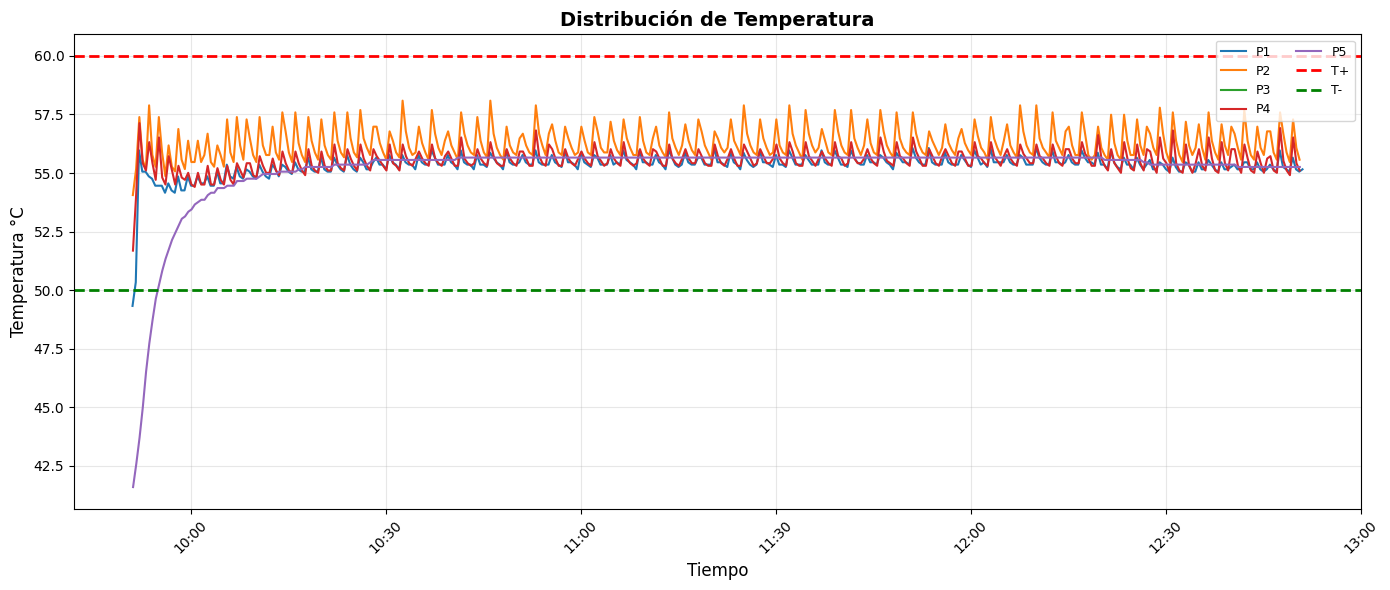

✅ Gráfica 1: Distribución generada


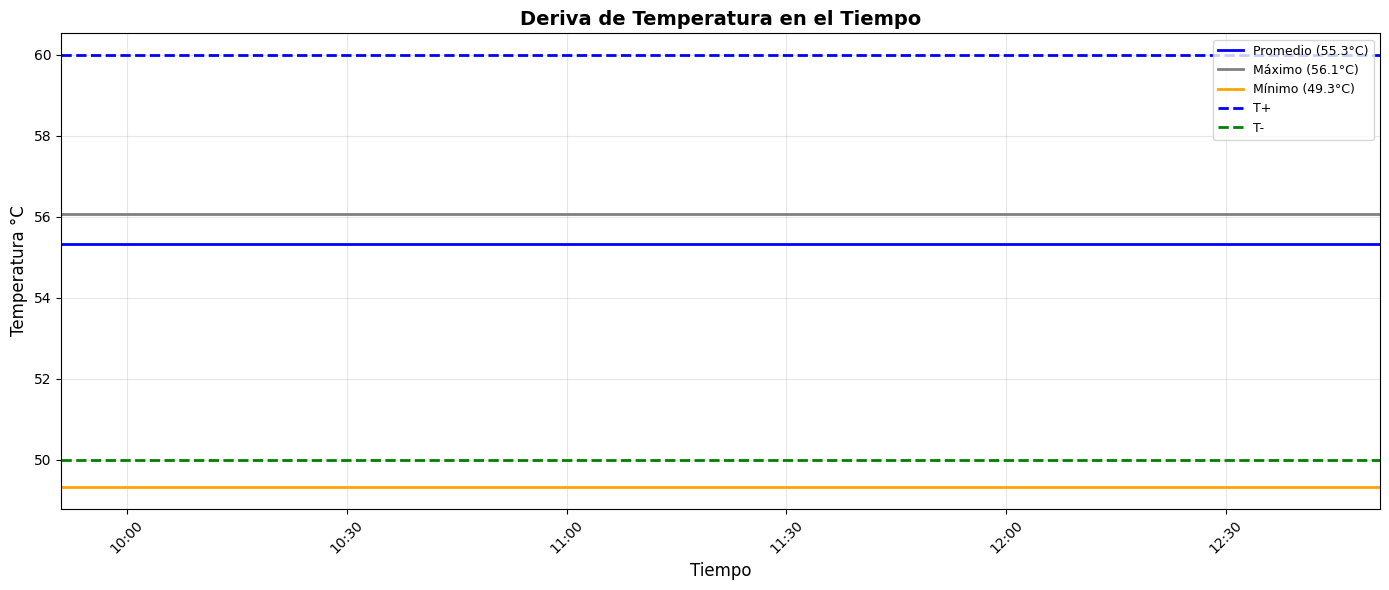

✅ Gráfica 2: Deriva generada


In [ ]:
# Configuración de estilo
plt.style.use('default')
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
           '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

print("\n📊 GENERANDO GRÁFICAS...")
print("="*60)

# GRÁFICA 1: Distribución de Temperatura
fig1, ax1 = plt.subplots(figsize=(14, 6))

# Graficar cada sensor (usando datos corregidos)
for i, sensor_name in enumerate(nombres_sensores):
    df = datos_procesados[sensor_name]
    ax1.plot(df['Tiempo'], df['Temperatura_Corregida'],
             label=f'P{i+1}', color=colores[i % len(colores)], linewidth=1.5)

# Líneas de referencia
ax1.axhline(y=T_plus, color='red', linestyle='--', linewidth=2, label='T+')
ax1.axhline(y=T_minus, color='green', linestyle='--', linewidth=2, label='T-')

ax1.set_xlabel('Tiempo', fontsize=12)
ax1.set_ylabel('Temperatura °C', fontsize=12)
ax1.set_title('Distribución de Temperatura', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9, ncol=2)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('distribucion_temperatura.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica 1: Distribución generada")

# GRÁFICA 2: Deriva (Sensor P1)
fig2, ax2 = plt.subplots(figsize=(14, 6))

sensor_centrico = nombres_sensores[0]
stats_centrico = estadisticas[sensor_centrico]

ax2.axhline(y=stats_centrico['promedio'], color='blue', linewidth=2,
            label=f"Promedio ({stats_centrico['promedio']:.1f}°C)")
ax2.axhline(y=stats_centrico['maximo'], color='gray', linewidth=2,
            label=f"Máximo ({stats_centrico['maximo']:.1f}°C)")
ax2.axhline(y=stats_centrico['minimo'], color='orange', linewidth=2,
            label=f"Mínimo ({stats_centrico['minimo']:.1f}°C)")
ax2.axhline(y=T_plus, color='blue', linestyle='--', linewidth=2, label='T+')
ax2.axhline(y=T_minus, color='green', linestyle='--', linewidth=2, label='T-')

ax2.set_xlabel('Tiempo', fontsize=12)
ax2.set_ylabel('Temperatura °C', fontsize=12)
ax2.set_title('Deriva de Temperatura en el Tiempo', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(fecha_inicio, fecha_fin)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('deriva_temperatura.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica 2: Deriva generada")
print("="*60)

## 💾 Paso 8: Exportar a Excel (VERSIÓN ULTIMATE)

In [ ]:
# Crear archivo Excel
nombre_archivo_excel = f'Reporte_Temperatura_{fecha_inicio.strftime("%Y%m%d")}_{fecha_fin.strftime("%Y%m%d")}.xlsx'

print("\n💾 EXPORTANDO A EXCEL...")
print("="*60)

with pd.ExcelWriter(nombre_archivo_excel, engine='xlsxwriter') as writer:
    workbook = writer.book

    # ========== HOJA 1: Resumen ==========
    print("📊 Creando hoja: Resumen...")

    info_general = pd.DataFrame({
        'Parámetro': [
            'ESTUDIO DISTRIBUCIÓN DE LA TEMPERATURA',
            '', 'Fecha Inicio', 'Fecha Fin', 'Duración', '',
            'Setpoint', 'Tolerancia', 'T+', 'T-', '',
            'Tasa de Muestreo',
            'Número de Sensores', 'Sensores', 'Sensor Céntrico (P1)'
        ],
        'Valor': [
            '', '',
            fecha_inicio.strftime('%Y-%m-%d %H:%M:%S'),
            fecha_fin.strftime('%Y-%m-%d %H:%M:%S'),
            duracion_str, '',
            f"{setpoint}°C", f"±{tolerancia}°C",
            f"{T_plus}°C", f"{T_minus}°C", '',
            tasa_nombre,
            len(nombres_sensores),
            ', '.join(nombres_sensores),
            nombres_sensores[0]
        ]
    })

    info_general.to_excel(writer, sheet_name='Resumen', index=False, startrow=0)
    df_tabla.to_excel(writer, sheet_name='Resumen', index=False, startrow=len(info_general) + 2)

    criterio_df = pd.DataFrame({
        'Criterio': [f'Rango: {T_minus}°C a {T_plus}°C'],
        'Resultado': [f'Promedio: {temp_promedio_general:.1f}°C - {"DENTRO" if cumple_criterio else "FUERA"}'],
        'Cumple': ['SÍ' if cumple_criterio else 'NO']
    })
    criterio_df.to_excel(writer, sheet_name='Resumen', index=False,
                        startrow=len(info_general) + len(df_tabla) + 4)

    # ========== HOJA 2 y 3: Gráficas PNG ==========
    print("📈 Insertando gráficas...")

    worksheet_graf1 = workbook.add_worksheet('Gráfica Distribución')
    worksheet_graf1.insert_image('B2', 'distribucion_temperatura.png', {'x_scale': 0.8, 'y_scale': 0.8})

    worksheet_graf2 = workbook.add_worksheet('Gráfica Deriva')
    worksheet_graf2.insert_image('B2', 'deriva_temperatura.png', {'x_scale': 0.8, 'y_scale': 0.8})

    # ========== HOJA 4: Datos SIN Corrección ==========
    print("📋 Creando hoja: Datos SIN Corrección...")

    df_sin_export = df_sin_correccion.copy()
    df_sin_export['Tiempo'] = df_sin_export['Tiempo'].dt.strftime('%Y-%m-%d %H:%M:%S')
    df_sin_export.to_excel(writer, sheet_name='Datos SIN Corrección', index=False)
    print(f"   ✓ {len(df_sin_export)} registros exportados")

    # ========== HOJA 5: Datos CON Corrección ==========
    print("📋 Creando hoja: Datos CON Corrección...")

    df_con_export = df_con_correccion.copy()
    df_con_export['Tiempo'] = df_con_export['Tiempo'].dt.strftime('%Y-%m-%d %H:%M:%S')
    df_con_export.to_excel(writer, sheet_name='Datos CON Corrección', index=False)
    print(f"   ✓ {len(df_con_export)} registros exportados")
    print(f"   ✓ Incluye correcciones aplicadas")

    # ========== HOJA 6: Trazabilidad ==========
    print("📊 Creando hoja: Trazabilidad...")

    traz_list = []
    for i, sensor_name in enumerate(nombres_sensores, 1):
        t = trazabilidad[sensor_name]
        traz_list.append({
            'Sensor': f'P{i}',
            'Nombre': sensor_name,
            'T1 (°C)': t['T1'],
            'C1 (°C)': t['C1'],
            'T2 (°C)': t['T2'],
            'C2 (°C)': t['C2'],
            'Pendiente m': pendientes[sensor_name]
        })

    df_traz = pd.DataFrame(traz_list)
    df_traz.to_excel(writer, sheet_name='Trazabilidad', index=False)

    # ========== HOJA 7: Estadísticas ==========
    print("📊 Creando hoja: Estadísticas...")

    stats_list = []
    for i, sensor_name in enumerate(nombres_sensores, 1):
        stats = estadisticas[sensor_name]
        stats_list.append({
            'Sensor': f'P{i}',
            'Nombre': sensor_name,
            'Promedio (°C)': f"{stats['promedio']:.2f}",
            'Máximo (°C)': f"{stats['maximo']:.2f}",
            'Mínimo (°C)': f"{stats['minimo']:.2f}",
            'Variación (°C)': f"{stats['variacion']:.2f}",
            'Desv. Est. (°C)': f"{stats['desvest']:.2f}"
        })

    df_stats = pd.DataFrame(stats_list)
    df_stats.to_excel(writer, sheet_name='Estadísticas', index=False)

    stats_gen = pd.DataFrame({
        'Parámetro': [
            'Temperatura Promedio General',
            'Gradiente (Caliente - Frío)',
            'Variación (MAX dif. con P1)',
            'Estabilidad (MAX Desv.Est. × 2)',
            'Temperatura Máxima',
            'Temperatura Mínima'
        ],
        'Valor (°C)': [
            f"{temp_promedio_general:.2f}",
            f"{gradiente_temperatura:.2f}",
            f"{variacion_temp_general:.2f}",
            f"{estabilidad_temperatura:.2f}",
            f"{temp_maxima_registrada:.2f}",
            f"{temp_minima_registrada:.2f}"
        ]
    })
    stats_gen.to_excel(writer, sheet_name='Estadísticas', index=False, startrow=len(df_stats) + 3)

    # Formatear columnas
    for sheet in ['Resumen', 'Datos SIN Corrección', 'Datos CON Corrección', 'Trazabilidad', 'Estadísticas']:
        if sheet in writer.sheets:
            writer.sheets[sheet].set_column('A:Z', 20)

print("\n" + "="*60)
print("✅ EXCEL CREADO EXITOSAMENTE")
print("="*60)
print(f"\n📊 Archivo: {nombre_archivo_excel}")
print("\n📋 HOJAS:")
print("   1. Resumen - Configuración y resultados")
print("   2. Gráfica Distribución - PNG")
print("   3. Gráfica Deriva - PNG")
print("   4. Datos SIN Corrección - Tabla completa")
print("   5. Datos CON Corrección - Tabla con correcciones")
print("   6. Trazabilidad - Certificados de calibración")
print("   7. Estadísticas - Resumen estadístico")
print(f"\n⏱️  Tasa de muestreo: {tasa_nombre}")
print(f"📏 Corrección: Por interpolación (variable)")

print("\n📥 Descargando...")
files.download(nombre_archivo_excel)

print("\n" + "="*60)
print("🎉 VERSIÓN 8 ULTIMATE - COMPLETADA")
print("="*60)
print("\n✨ CARACTERÍSTICAS:")
print("   ✅ Corrección por interpolación")
print("   ✅ Tasa de muestreo seleccionable")
print("   ✅ Sin pérdida de datos")
print("   ✅ Gráficas PNG insertadas")
print("   ✅ Datos completos sin/con corrección")
print("   ✅ Trazabilidad documentada")
print("\n🔄 Para nuevo análisis: Runtime → Restart runtime")
print("\n¡Gracias por usar el Sistema v8 ULTIMATE! 🚀")


💾 EXPORTANDO A EXCEL...
📊 Creando hoja: Resumen...
📈 Insertando gráficas...
📋 Creando hoja: Datos SIN Corrección...
   ✓ 361 registros exportados
📋 Creando hoja: Datos CON Corrección...
   ✓ 361 registros exportados
   ✓ Incluye correcciones aplicadas
📊 Creando hoja: Trazabilidad...
📊 Creando hoja: Estadísticas...

✅ EXCEL CREADO EXITOSAMENTE

📊 Archivo: Reporte_Temperatura_20260122_20260122.xlsx

📋 HOJAS:
   1. Resumen - Configuración y resultados
   2. Gráfica Distribución - PNG
   3. Gráfica Deriva - PNG
   4. Datos SIN Corrección - Tabla completa
   5. Datos CON Corrección - Tabla con correcciones
   6. Trazabilidad - Certificados de calibración
   7. Estadísticas - Resumen estadístico

⏱️  Tasa de muestreo: 30 segundos
📏 Corrección: Por interpolación (variable)

📥 Descargando...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 VERSIÓN 8 ULTIMATE - COMPLETADA

✨ CARACTERÍSTICAS:
   ✅ Corrección por interpolación
   ✅ Tasa de muestreo seleccionable
   ✅ Sin pérdida de datos
   ✅ Gráficas PNG insertadas
   ✅ Datos completos sin/con corrección
   ✅ Trazabilidad documentada

🔄 Para nuevo análisis: Runtime → Restart runtime

¡Gracias por usar el Sistema v8 ULTIMATE! 🚀
